In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

### **Data Loading**

In [15]:
file_path = "online_retail_customer_data_extended.csv"
df = pd.read_csv(file_path)

print("Dataset Shape:", df.shape)
print("\nColumn Names:\n", df.columns.tolist())

print("\nData Types:\n")
print(df.dtypes)

Dataset Shape: (9000, 17)

Column Names:
 ['CustomerID', 'Age', 'Gender', 'Annual_Income_USD', 'Spending_Score', 'Membership_Status', 'Preferred_Payment_Method', 'Region', 'Total_Purchases', 'Avg_Purchase_Value', 'Last_Purchase_Date', 'Churn', 'Satisfaction_Score', 'Website_Visits_Last_Month', 'Avg_Time_Per_Visit_Minutes', 'Support_Tickets_Last_6_Months', 'Referred_Friends']

Data Types:

CustomerID                        object
Age                                int64
Gender                            object
Annual_Income_USD                  int64
Spending_Score                     int64
Membership_Status                 object
Preferred_Payment_Method          object
Region                            object
Total_Purchases                    int64
Avg_Purchase_Value               float64
Last_Purchase_Date                object
Churn                              int64
Satisfaction_Score               float64
Website_Visits_Last_Month          int64
Avg_Time_Per_Visit_Minutes       f

In [16]:
print("\nFirst 5 Rows:\n")
print(df.head())


First 5 Rows:

                             CustomerID  Age  Gender  Annual_Income_USD  \
0  2f8c8c58-4779-4006-aa23-81db3a352da3   56  Female              79228   
1  4e6558a6-7f45-4f2a-8dfc-fb05210c5a54   69  Female              23205   
2  11ab8d14-6dd9-4a49-84cc-963431a8e6fc   46    Male              54929   
3  503e4ec0-42c7-4c2d-8cda-a480ad492b4b   32  Female             103384   
4  841426ba-7371-43b1-9cba-036d07d6c85e   60    Male              53411   

   Spending_Score Membership_Status Preferred_Payment_Method   Region  \
0              73            Bronze           Cryptocurrency  Central   
1              65            Silver           Cryptocurrency  Central   
2              68            Bronze               Debit Card  Central   
3              71            Bronze                   PayPal  Central   
4              11            Silver                   PayPal     West   

   Total_Purchases  Avg_Purchase_Value Last_Purchase_Date  Churn  \
0               17        

In [17]:
print("\nChurn Distribution:\n")
print(df["Churn"].value_counts())


Churn Distribution:

Churn
0    7224
1    1776
Name: count, dtype: int64


In [18]:
# Missing values overview
missing_counts = df.isna().sum().sort_values(ascending=False)
missing_percent = (missing_counts / len(df) * 100).round(2)
missing_report = pd.DataFrame({
    "Missing_Count": missing_counts,
    "Missing_%": missing_percent
})

print("Total missing values:", missing_counts.sum())
print("\nMissing values by column (non-zero only, sorted):")
print(missing_report[missing_report["Missing_Count"] > 0])

Total missing values: 0

Missing values by column (non-zero only, sorted):
Empty DataFrame
Columns: [Missing_Count, Missing_%]
Index: []


### **Data Cleaning and Preprocessing**

In [19]:
# So first we will drop the CustomerID column as it is not useful for prediction
df.drop(columns=["CustomerID"], inplace=True)

# Next we will fix the Data Types

df["Last_Purchase_Date"] = pd.to_datetime(df["Last_Purchase_Date"], errors="coerce", dayfirst=True)

numeric_columns = [
    "Age",
    "Annual_Income_USD",
    "Spending_Score",
    "Total_Purchases",
    "Avg_Purchase_Value",
    "Satisfaction_Score",
    "Website_Visits_Last_Month",
    "Avg_Time_Per_Visit_Minutes",
    "Support_Tickets_Last_6_Months",
    "Referred_Friends"
]

categorical_columns = [
    "Gender",
    "Membership_Status",
    "Preferred_Payment_Method",
    "Region"
]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Next step is Handling Missing Values for the numerical value we will fill missing values with median and for categorical we will fill with mode
for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median())

for col in categorical_columns:
    mode_vals = df[col].mode()
    if not mode_vals.empty:
        df[col] = df[col].fillna(mode_vals[0])

# Target variable should not have missing values
df = df[df["Churn"].notna()]

# Next we will handle the Invalid Values
df = df[(df["Age"] >= 18) & (df["Age"] <= 100)]

df = df[(df["Annual_Income_USD"] >= 0) & (df["Avg_Purchase_Value"] >= 0)]

In [20]:
print("\nData after preprocessing:")
print(df.head())


Data after preprocessing:
   Age  Gender  Annual_Income_USD  Spending_Score Membership_Status  \
0   56  Female              79228              73            Bronze   
1   69  Female              23205              65            Silver   
2   46    Male              54929              68            Bronze   
3   32  Female             103384              71            Bronze   
4   60    Male              53411              11            Silver   

  Preferred_Payment_Method   Region  Total_Purchases  Avg_Purchase_Value  \
0           Cryptocurrency  Central               17              209.07   
1           Cryptocurrency  Central               21               25.60   
2               Debit Card  Central               25              105.48   
3                   PayPal  Central               25              381.95   
4                   PayPal     West               24              319.19   

  Last_Purchase_Date  Churn  Satisfaction_Score  Website_Visits_Last_Month  \
0         2

### **Exploratory Data Analysis**

In [21]:
# Basic descriptive statistics and data overview
print(df.describe(include='all'))

# Distribution of numeric variables using histograms
numeric_df = df.select_dtypes(include=[np.number])



                Age Gender  Annual_Income_USD  Spending_Score  \
count   9000.000000   9000        9000.000000     9000.000000   
unique          NaN      3                NaN             NaN   
top             NaN   Male                NaN             NaN   
freq            NaN   4399                NaN             NaN   
mean      43.550444    NaN       84932.292222       49.764222   
min       18.000000    NaN       20014.000000        1.000000   
25%       31.000000    NaN       51436.000000       25.000000   
50%       43.000000    NaN       85389.500000       49.000000   
75%       56.000000    NaN      117357.000000       75.000000   
max       69.000000    NaN      149997.000000       99.000000   
std       14.909264    NaN       37649.418701       28.693640   

       Membership_Status Preferred_Payment_Method   Region  Total_Purchases  \
count               9000                     9000     9000      9000.000000   
unique                 4                        4        5   

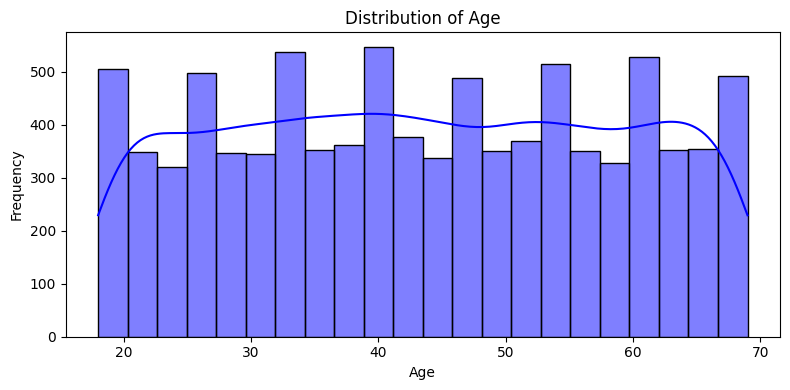

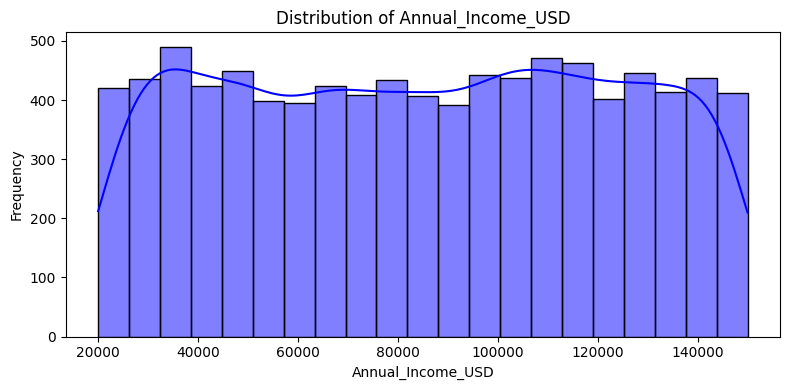

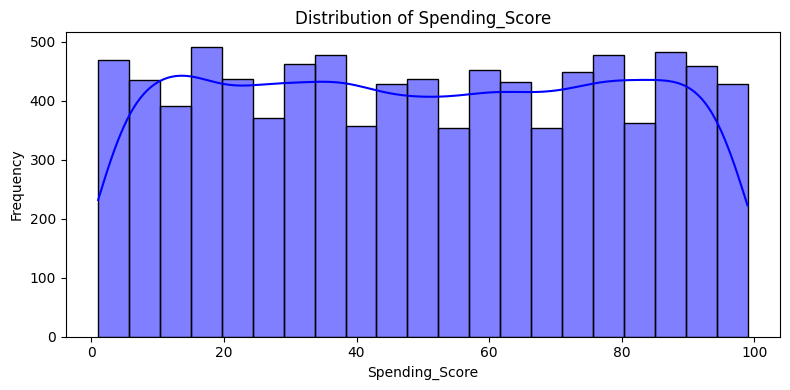

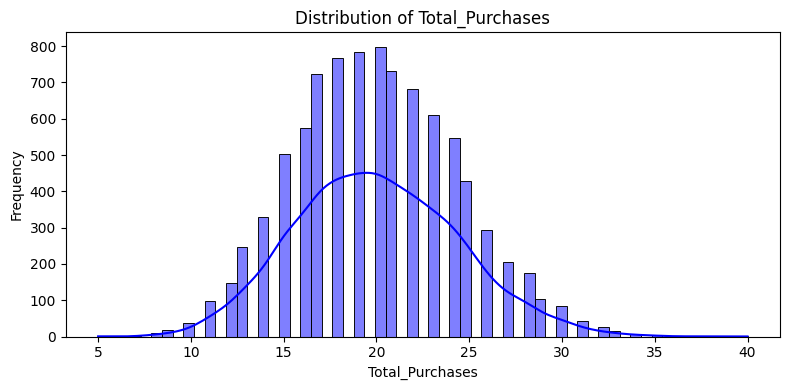

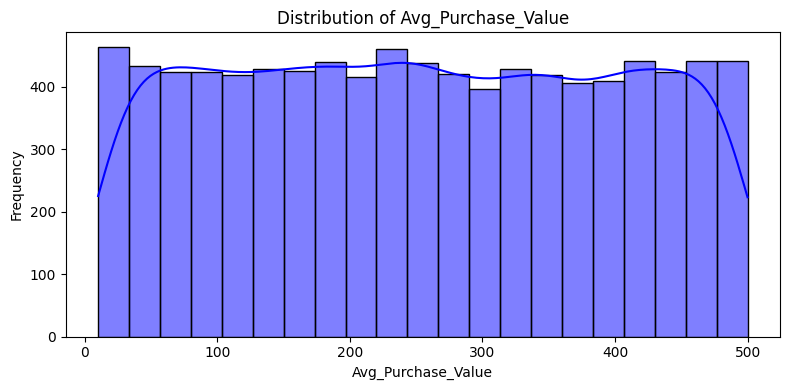

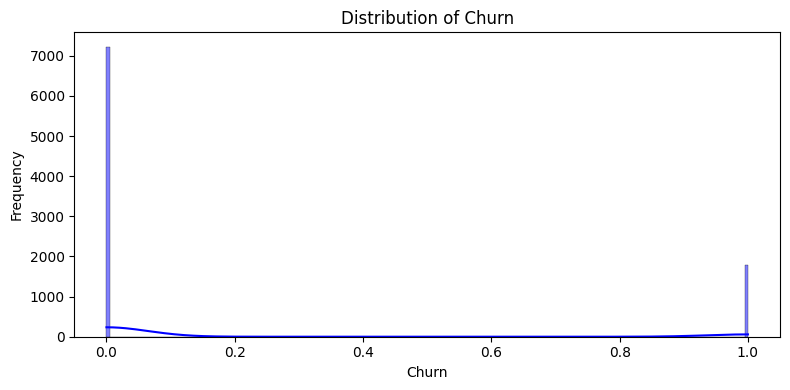

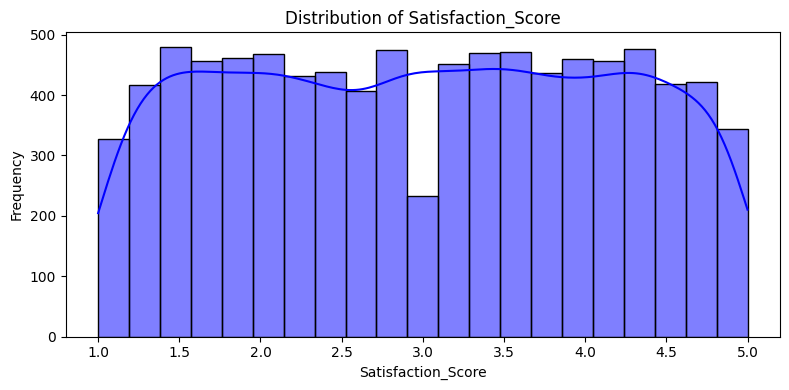

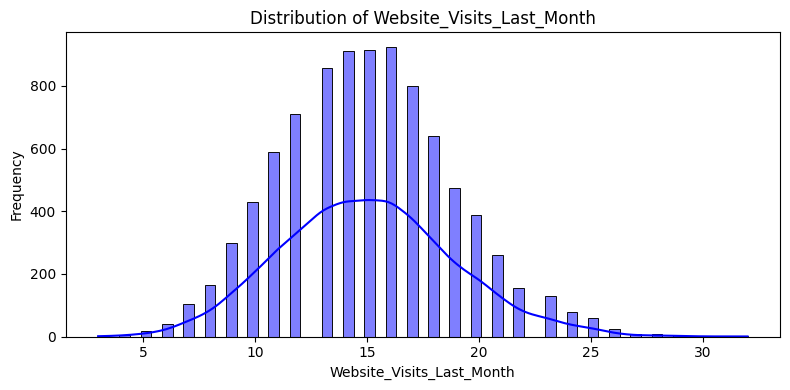

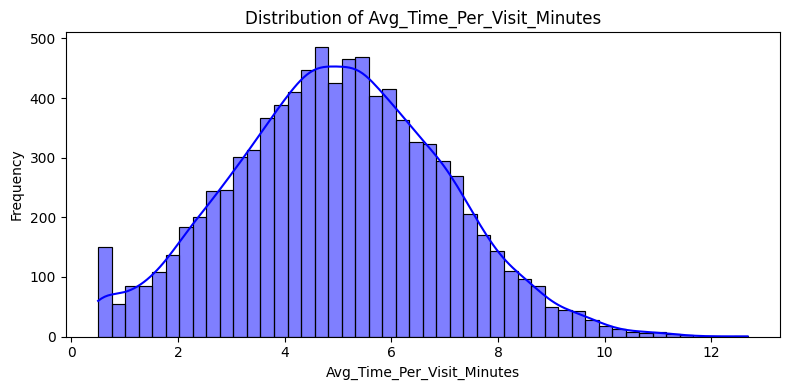

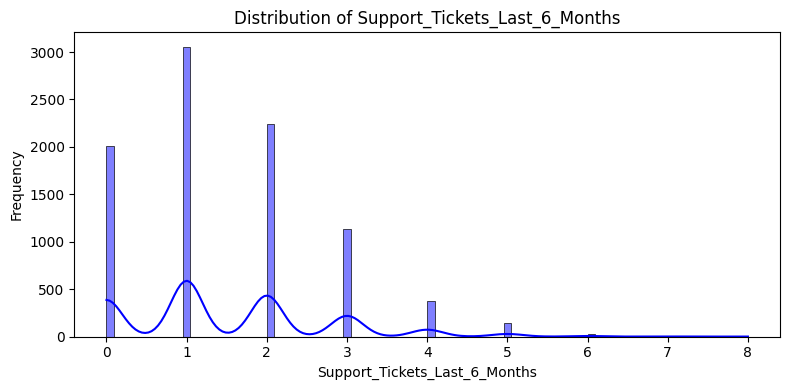

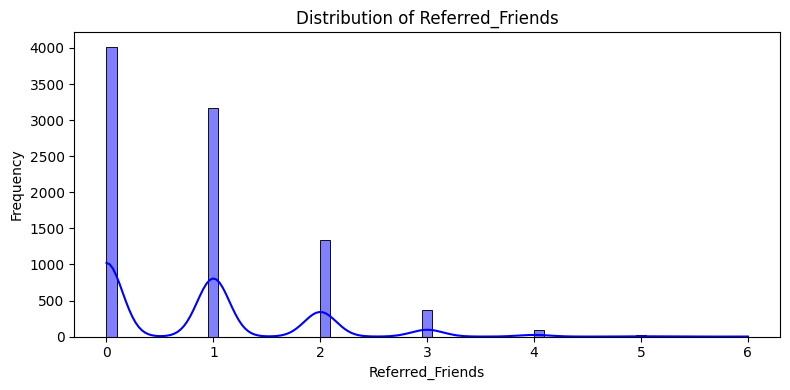

C:\Users\kravi\AppData\Local\Temp\ipykernel_18808\2343552427.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Preferred_Payment_Method', palette='viridis')


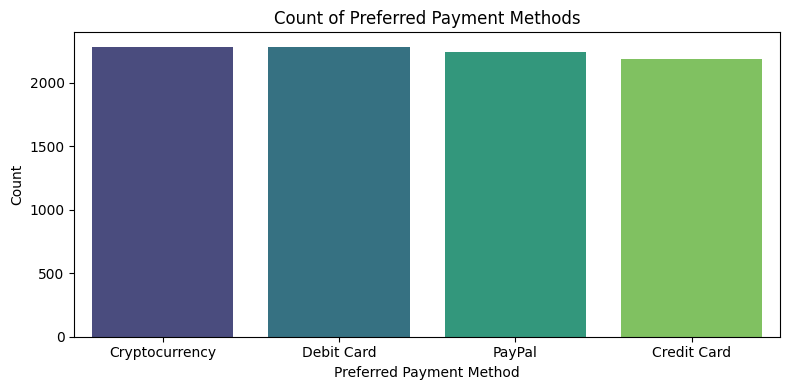

In [22]:

for col in numeric_df.columns:
    plt.figure(figsize=(8, 4))
    sns.histplot(numeric_df[col], kde=True, color='blue')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

# Count plots for categorical variables (Using Preferred Payment Method as an example)
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='Preferred_Payment_Method', palette='viridis')
plt.title('Count of Preferred Payment Methods')
plt.xlabel('Preferred Payment Method')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

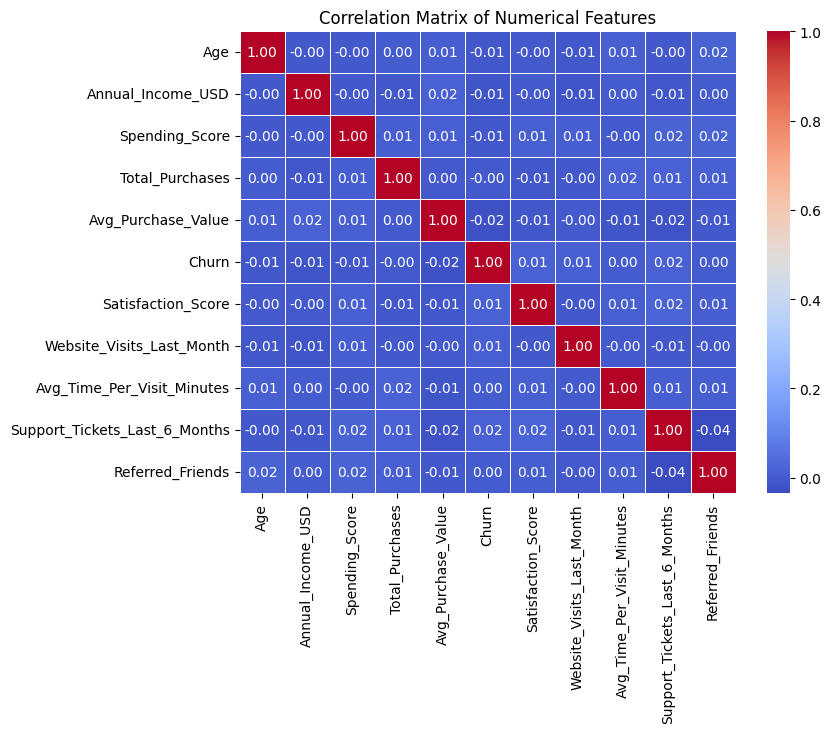

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numerical columns for correlation matrix
numerical_df = df.select_dtypes(include=['number'])

# Calculate the correlation matrix
corr_matrix = numerical_df.corr()

# Plotting the heatmap
plt.figure(figsize=(8, 6))  # Reduced figure size
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

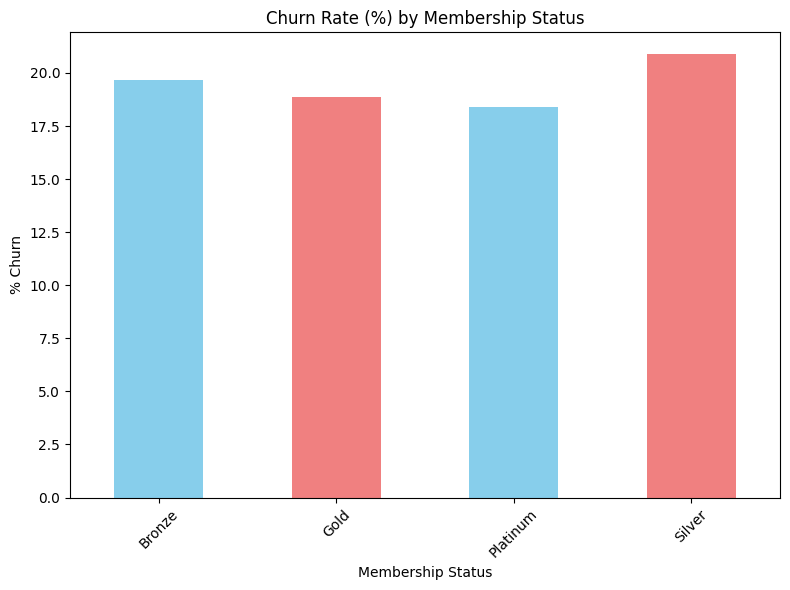

In [24]:
# 1. Membership_Status (x-axis) with % Churn (Bar Chart)
plt.figure(figsize=(8, 6))
churn_by_membership = df.groupby('Membership_Status')['Churn'].mean() * 100  # % Churn
churn_by_membership.plot(kind='bar', color=['skyblue', 'lightcoral'])
plt.title('Churn Rate (%) by Membership Status')
plt.ylabel('% Churn')
plt.xlabel('Membership Status')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

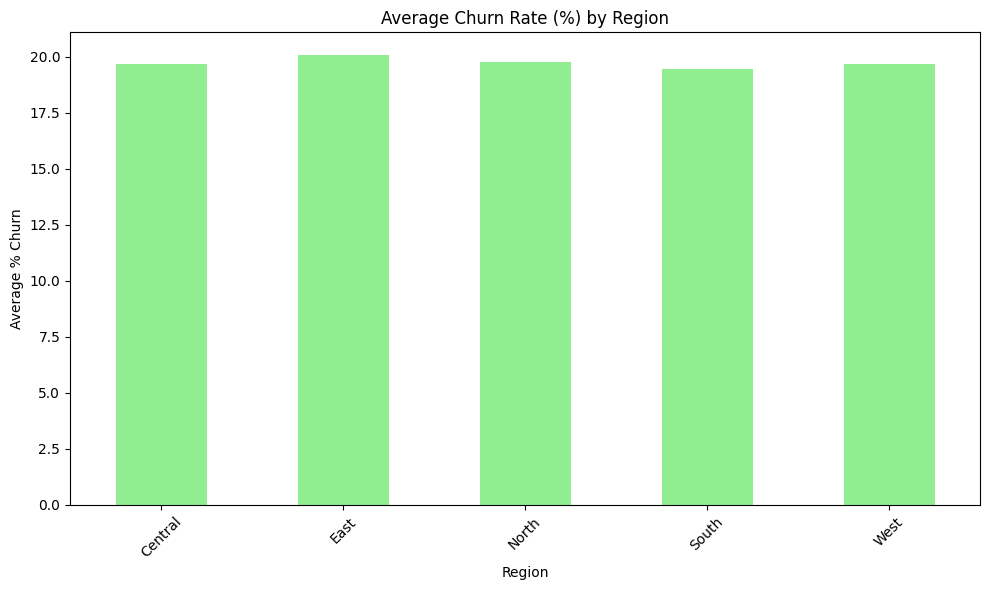

In [25]:
# 2. Region (x-axis) with average Churn Rate (y-axis) - Bar Chart
plt.figure(figsize=(10, 6))
churn_by_region = df.groupby('Region')['Churn'].mean() * 100  # % Churn
churn_by_region.plot(kind='bar', color='lightgreen')
plt.title('Average Churn Rate (%) by Region')
plt.ylabel('Average % Churn')
plt.xlabel('Region')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\kravi\AppData\Local\Temp\ipykernel_18808\1254446386.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_counts = df.groupby(['Age_Decade', 'Churn']).size().unstack(fill_value=0)


<Figure size 1000x600 with 0 Axes>

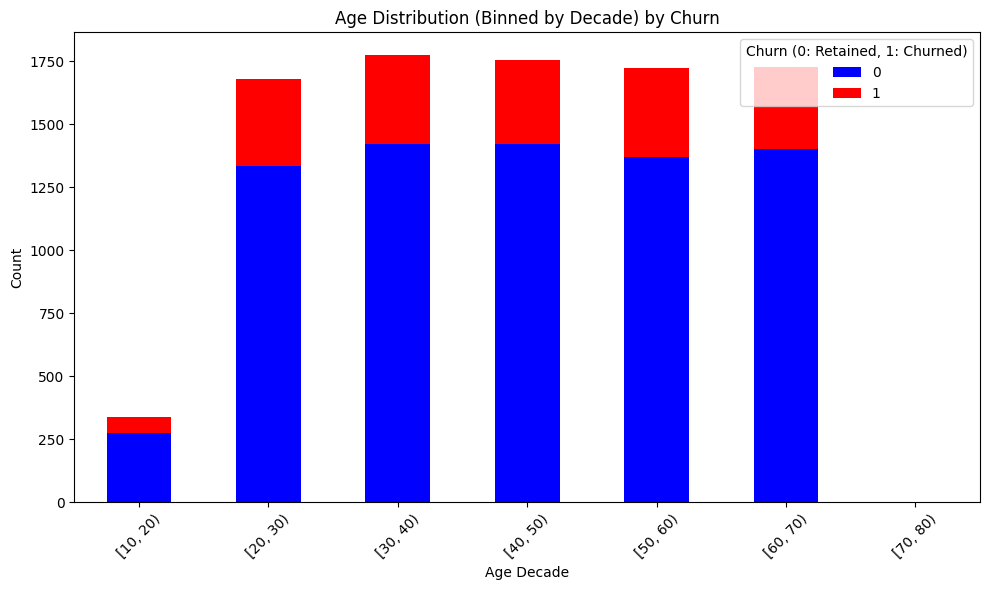

In [26]:
# 3. Age (x-axis, binned by decade) overlaid by Churn density (two colors) - Binned Histogram
plt.figure(figsize=(10, 6))
age_bins = range(10, 90, 10)  
df['Age_Decade'] = pd.cut(df['Age'], bins=age_bins, right=False)
# Plot stacked histogram for overlaid view
churn_counts = df.groupby(['Age_Decade', 'Churn']).size().unstack(fill_value=0)
churn_counts.plot(kind='bar', stacked=True, color=['blue', 'red'], figsize=(10, 6))
plt.title('Age Distribution (Binned by Decade) by Churn')
plt.xlabel('Age Decade')
plt.ylabel('Count')
plt.legend(title='Churn (0: Retained, 1: Churned)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

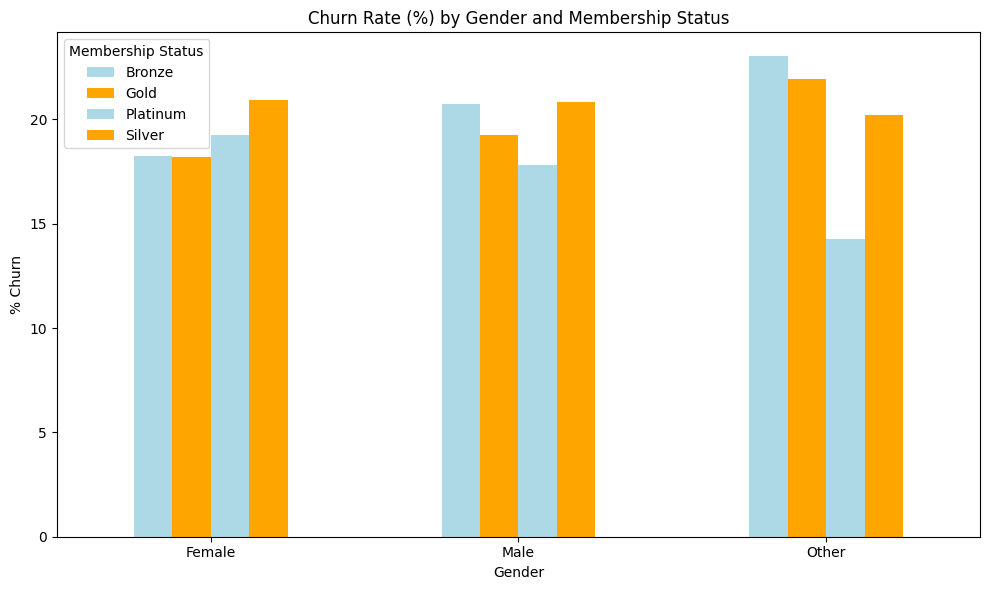

In [27]:
# 4. Gender (x-axis) grouped by Membership_Status, with Churn Rate (y-axis) - Grouped Bar Chart
plt.figure(figsize=(10, 6))
pivot_churn = df.groupby(['Gender', 'Membership_Status'])['Churn'].mean().unstack() * 100
pivot_churn.plot(kind='bar', figsize=(10, 6), color=['lightblue', 'orange'])
plt.title('Churn Rate (%) by Gender and Membership Status')
plt.ylabel('% Churn')
plt.xlabel('Gender')
plt.legend(title='Membership Status')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

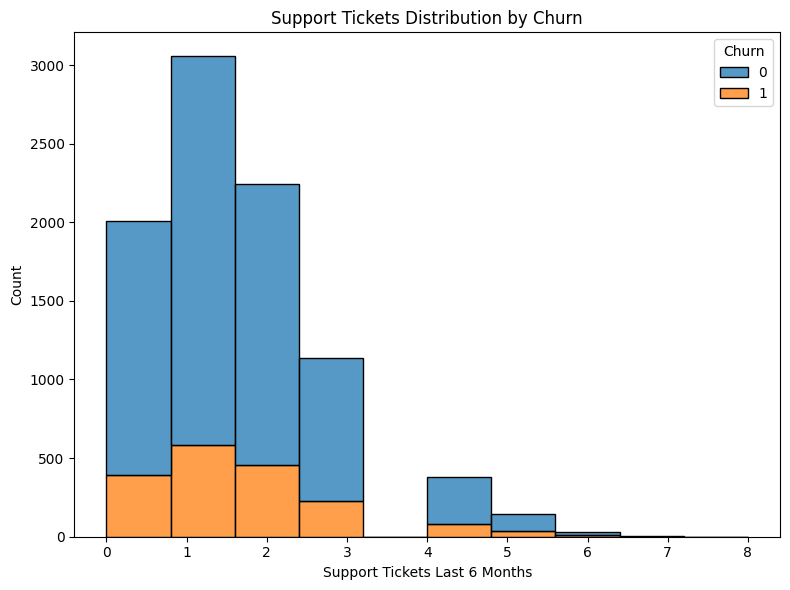

In [28]:
#6. Support_Tickets_Last_6_Months (x-axis) overlaid by Churn density (two colors) - Stacked Histogram
plt.figure(figsize=(8, 6))
sns.histplot(
    data=df,
    x='Support_Tickets_Last_6_Months',
    hue='Churn',
    bins=10,
    kde=False,
    multiple='stack'
)
plt.title('Support Tickets Distribution by Churn')
plt.xlabel('Support Tickets Last 6 Months')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


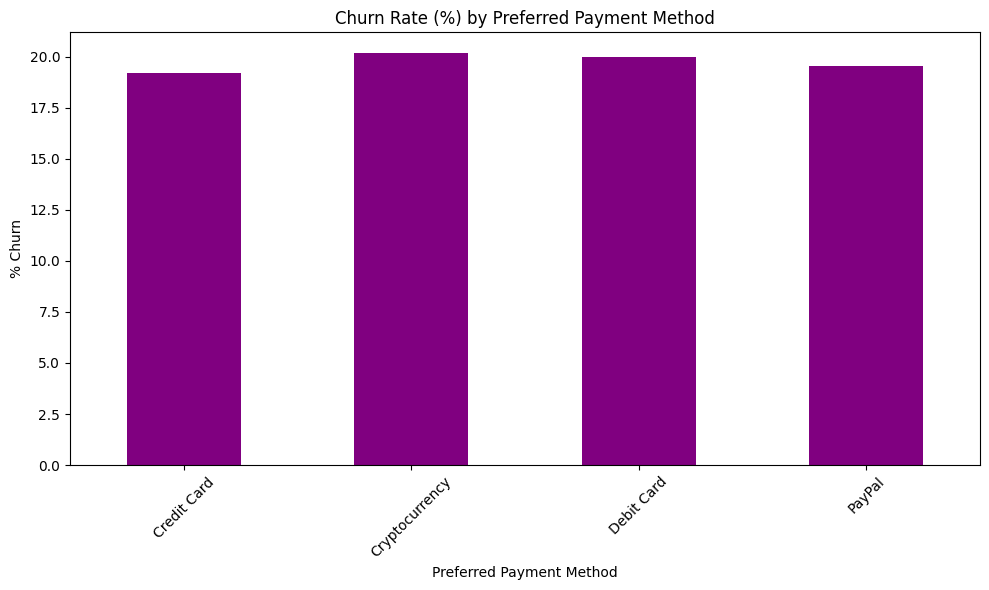

In [29]:
# 7. Preferred_Payment_Method (x-axis) with % Churn (y-axis) - Bar Chart
plt.figure(figsize=(10, 6))
churn_by_payment = df.groupby('Preferred_Payment_Method')['Churn'].mean() * 100
churn_by_payment.plot(kind='bar', color='purple')
plt.title('Churn Rate (%) by Preferred Payment Method')
plt.ylabel('% Churn')
plt.xlabel('Preferred Payment Method')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### **Feature Engineering**

In [30]:
# Next is that we will Encode Categorical Variables

gender_encoder = LabelEncoder()
df["Gender"] = gender_encoder.fit_transform(df["Gender"]) # So I am keeping 0 - Female and 1 - Male

df = pd.get_dummies(
    df,
    columns=["Membership_Status", "Preferred_Payment_Method", "Region"],
    drop_first=True
)

In [31]:
# Recency Feature

reference_date = df["Last_Purchase_Date"].max()

df["Days_Since_Last_Purchase"] = (
    reference_date - df["Last_Purchase_Date"]
).dt.days

df["Days_Since_Last_Purchase"] = df["Days_Since_Last_Purchase"].fillna(
    df["Days_Since_Last_Purchase"].median()
)

# Next is the Purchase Behavior Features

df["Total_Spend"] = df["Total_Purchases"] * df["Avg_Purchase_Value"]

df["Avg_Spend_Per_Visit"] = np.where(
    df["Website_Visits_Last_Month"] > 0,
    df["Total_Spend"] / df["Website_Visits_Last_Month"],
    0
)

df["Engagement_Score"] = (
    df["Website_Visits_Last_Month"] * df["Avg_Time_Per_Visit_Minutes"]
)

# Next is the Loyalty Features
df["Is_Loyal_Customer"] = np.where(
    (df["Referred_Friends"] > 0) |
    (df.filter(like="Membership_Status_").sum(axis=1) > 0),
    1,
    0
)

# Next is the Support Risk Feature

df["Support_Risk_Score"] = (
    df["Support_Tickets_Last_6_Months"] *
    (5 - df["Satisfaction_Score"])
)  # so here higher value means higher churn risk

# Next we will drop the redundant columns
df.drop(columns=["Last_Purchase_Date"], inplace=True)


print("\nShape after feature engineering:", df.shape)
print("\nEngineered feature preview:")
print(df.head())


Shape after feature engineering: (9000, 29)

Engineered feature preview:
   Age  Gender  Annual_Income_USD  Spending_Score  Total_Purchases  \
0   56       0              79228              73               17   
1   69       0              23205              65               21   
2   46       1              54929              68               25   
3   32       0             103384              71               25   
4   60       1              53411              11               24   

   Avg_Purchase_Value  Churn  Satisfaction_Score  Website_Visits_Last_Month  \
0              209.07      0                 2.3                          7   
1               25.60      0                 2.5                         14   
2              105.48      0                 4.6                         18   
3              381.95      1                 4.9                         20   
4              319.19      0                 1.2                         18   

   Avg_Time_Per_Visit_Minutes 

### **Model Training**

In [ ]:
# For training first we will separate Features & Target and then do the Train - Test Split

X = df.drop(columns=["Churn"])
y = df["Churn"]

print("Target Distribution:")
print(y.value_counts(normalize=True))


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTrain shape:", X_train.shape)
print("Test shape:", X_test.shape)

# Then the next we will do the Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)